# Lab 1: Calibration of a CMOS

### Importing everything we'll need at the beginning

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import glob
from astropy.io import fits 
import derryck

In [5]:
file_path = 'ASTR362-Lab1/Seamus_Derryck_Lab1/'

theta_ceph = sorted(glob.glob(file_path + 'Al*.fit'))
deneb = sorted(glob.glob(file_path + 'Deneb*.fit'))
kochab = sorted(glob.glob(file_path + 'Kochab*.fit'))
darks_10s = sorted(glob.glob(file_path + 'Darks1*.fit'))
darks_20s = sorted(glob.glob(file_path + 'Darks2*.fit'))
darks_30s = sorted(glob.glob(file_path + 'Darks3*.fit'))
bias = sorted(glob.glob(file_path + 'Bias*.fit'))
twilight = sorted(glob.glob(file_path + 'twilight*.fit'))

In [6]:
# I thought about just putting these in the derryck module, but for sake of clarity, I decided to keep them here


def get_data(hdul, data_shape):
    data = np.zeros(data_shape)
    for i in range(len(hdul)):
        data[i,:,:] = hdul[i].data
    return data

def read_all(list_of_files):
    hdul = fits.HDUList()
    for i in list_of_files:
        hdu = fits.open(i)
        hdul.append(hdu[0])
    return hdul

In [7]:
theta_ceph_hdul = read_all(theta_ceph)
deneb_hdul = read_all(deneb)
kochab_hdul = read_all(kochab)
darks_10s_hdul = read_all(darks_10s)
darks_20s_hdul = read_all(darks_20s)
darks_30s_hdul = read_all(darks_30s)
bias_hdul = read_all(bias)
twilight_hdul = read_all(twilight)

In [8]:
theta_ceph_data = derryck.sixteen_to_twelve_correction(get_data(theta_ceph_hdul, (10, 3522, 4656)))
deneb_data = derryck.sixteen_to_twelve_correction(get_data(deneb_hdul, (10, 3522, 4656)))
kochab_data = derryck.sixteen_to_twelve_correction(get_data(kochab_hdul, (10, 3522, 4656)))
darks_10s_data = derryck.sixteen_to_twelve_correction(get_data(darks_10s_hdul, (10, 3522, 4656)))
darks_20s_data = derryck.sixteen_to_twelve_correction(get_data(darks_20s_hdul, (10, 3522, 4656)))
darks_30s_data = derryck.sixteen_to_twelve_correction(get_data(darks_30s_hdul, (10, 3522, 4656)))
bias_data = derryck.sixteen_to_twelve_correction(get_data(bias_hdul, (20, 3522, 4656)))
twilight_data = derryck.sixteen_to_twelve_correction(get_data(twilight_hdul, (100, 3522, 4656)))

In [9]:
bias_mean = np.mean(bias_data,axis=0)
bias_median = np.median(bias_mean)
bias_median

153.65

Text(0.5, 1.0, 'Bias Mean Image: QHY 163M CMOS')

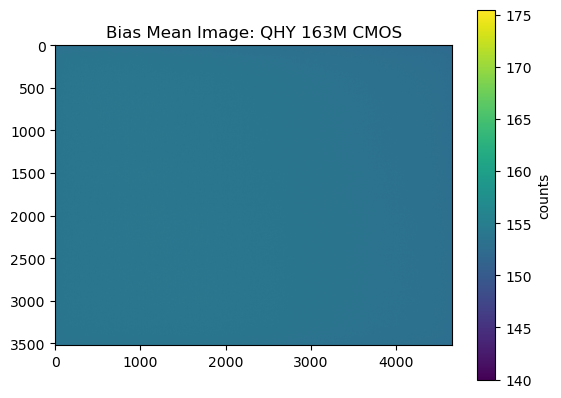

In [10]:
plt.imshow(bias_mean)
plt.colorbar(label='counts')
plt.title('Bias Mean Image: QHY 163M CMOS')

Text(0.5, 1.0, 'Bias Mean Image: QHY 163M CMOS')

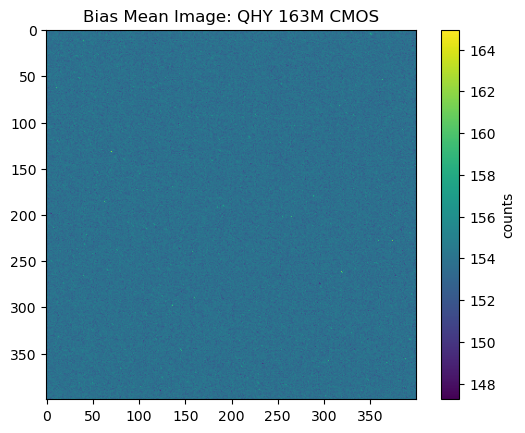

In [11]:
plt.imshow(bias_mean[1600:2000,2100:2500])
plt.colorbar(label='counts')
plt.title('Bias Mean Image: QHY 163M CMOS')

In [12]:
dark_10s_mean = np.mean(darks_10s_data,axis=0)
dark_20s_mean = np.mean(darks_20s_data,axis=0)
dark_30s_mean = np.mean(darks_30s_data,axis=0)

"plt.colorbar(label='counts')\nplt.subplot(312)\nplt.imshow(dark_20s_mean[1700:1900,2200:2400])\nplt.colorbar(label='counts')\nplt.subplot(313)\nplt.imshow(dark_30s_mean[1750:1800,2225:2275])\nplt.colorbar(label='counts')"

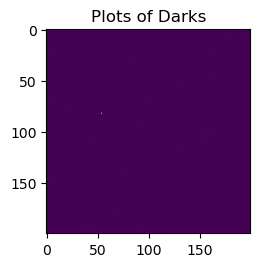

In [29]:
plt.figure(figsize=[9,9])
plt.subplot(311)
plt.imshow(dark_10s_mean[1700:1900,2200:2400])
plt.title('Plots of Darks')

'''plt.colorbar(label='counts')
plt.subplot(312)
plt.imshow(dark_20s_mean[1700:1900,2200:2400])
plt.colorbar(label='counts')
plt.subplot(313)
plt.imshow(dark_30s_mean[1750:1800,2225:2275])
plt.colorbar(label='counts')'''